Dataset: Coffee Quality Dataset (инструкция по выбору кофе)
Source: https://www.kaggle.com/datasets/fatihb/coffee-quality-data-cqi?select=df_arabica_clean.csv

Набор данных содержит результаты оценки кофейных зерен из разных стран.
Каждый образец кофе оценивается профессиональными дегустаторами по таким характеристикам, как аромат, кислотность,вкус, баланс и общее качество.

Цель этого ноутбука (и моя соответственно): провести аналитический анализ данных (EDA), очистить отсутствующие значения, кодировать категориальные переменные и исследовать взаимосвязи между характеристиками кофе.

In [231]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder

from sklearn.feature_extraction import FeatureHasher

df = pd.read_csv("C:/Users/HONOR/Downloads/df_arabica_clean.csv")

In [232]:
df.head(10)

df.tail()

,Unnamed: 0,ID,Country of Origin,Farm Name,Lot Number,Mill,ICO Number,Company,Altitude,Region,...,Total Cup Points,Moisture Percentage,Category One Defects,Quakers,Color,Category Two Defects,Expiration,Certification Body,Certification Address,Certification Contact
202,202,202,Brazil,Fazenda Conquista,019/22,Dry Mill,NaN,Ipanema Coffees,950,Sul de Minas,...,80.08,11.4,0,0,green,4,"February 2nd, 2024",Brazil Specialty Coffee Association,"Rua Gaspar Batista Paiva, 416 – Santa Luiza Va...",Chris Allen - 55 35 3212-4705
203,203,203,Nicaragua,Finca San Felipe,017-053-0155,Beneficio Atlantic Sébaco,017-053-0155,Exportadora Atlantic S.A,1200,Matagalpa,...,80.00,10.4,0,2,green,12,"March 2nd, 2024",Asociación de Cafés Especiales de Nicaragua,"Del Hotel Seminole 2 C al lago, 1 C arriba.",Maria Ines Benavidez Toval - 011-(505)-8396 4717
204,204,204,Laos,-,105/3/VL7285-005,DRY MILL,105/3/VL7285-005,Marubeni Corporation,1300,Bolaven Plateau,...,79.67,11.6,0,9,green,11,"November 11th, 2023",Japan Coffee Exchange,"〒413-0002 静岡県熱海市伊豆山１１７３−５８ 1173-58 Izusan, Ata...",松澤 宏樹 Koju Matsuzawa - +81(0)9085642901
205,205,205,El Salvador,"Rosario de Maria II, Area de La Pila",0423A01,"Optimum Coffee, San Salvador, El Salvador",NaN,Aprentium Enterprises LLC,1200,"Volcan de San Vicente, La Paz, El Salvador",...,78.08,11.0,0,12,bluish-green,13,"March 7th, 2024",Salvadoran Coffee Council,"Final 1a. Av. Norte y 13 Calle Pte., dentro de...",Tomas Bonilla - (503) 2505-6600
206,206,206,Brazil,Walter Matter,1058 y 1059,Beneficio humedo/seco,002/1208/1016,Descafeinadores Mexicano SA. de CV,850-1100,Minas Gerais,...,78.00,11.3,0,0,green,1,"November 18th, 2023",Centro Agroecológico del Café A.C.,"Instituto de Ecología A. C., Campus III Edific...",Stephany Escamilla Femat - Tel. +52 228 842180...


In [233]:
df.shape

(207, 41)

In [234]:
df.describe()


,Unnamed: 0,ID,Number of Bags,Aroma,Flavor,Aftertaste,Acidity,Body,Balance,Uniformity,Clean Cup,Sweetness,Overall,Defects,Total Cup Points,Moisture Percentage,Category One Defects,Quakers,Category Two Defects
count,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.00000,207.000000,207.000000,207.000000,207.0,207.0,207.000000,207.0,207.000000,207.000000,207.000000,207.000000,207.000000
mean,103.000000,103.000000,155.449275,7.721063,7.744734,7.599758,7.69029,7.640918,7.644058,9.990338,10.0,10.0,7.676812,0.0,83.706570,10.735266,0.135266,0.690821,2.251208
std,59.899917,59.899917,244.484868,0.287626,0.279613,0.275911,0.25951,0.233499,0.256299,0.103306,0.0,0.0,0.306359,0.0,1.730417,1.247468,0.592070,1.686918,2.950183
min,0.000000,0.000000,1.000000,6.500000,6.750000,6.670000,6.83000,6.830000,6.670000,8.670000,10.0,10.0,6.670000,0.0,78.000000,0.000000,0.000000,0.000000,0.000000
25%,51.500000,51.500000,1.000000,7.580000,7.580000,7.420000,7.50000,7.500000,7.500000,10.000000,10.0,10.0,7.500000,0.0,82.580000,10.100000,0.000000,0.000000,0.000000
50%,103.000000,103.000000,14.000000,7.670000,7.750000,7.580000,7.67000,7.670000,7.670000,10.000000,10.0,10.0,7.670000,0.0,83.750000,10.800000,0.000000,0.000000,1.000000
75%,154.500000,154.500000,275.000000,7.920000,7.920000,7.750000,7.87500,7.750000,7.790000,10.000000,10.0,10.0,7.920000,0.0,84.830000,11.500000,0.000000,1.000000,3.000000
max,206.000000,206.000000,2240.000000,8.580000,8.500000,8.420000,8.58000,8.250000,8.420000,10.000000,10.0,10.0,8.580000,0.0,89.330000,13.500000,5.000000,12.000000,16.000000


In [235]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 207 entries, 0 to 206
Data columns (total 41 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             207 non-null    int64  
 1   ID                     207 non-null    int64  
 2   Country of Origin      207 non-null    str    
 3   Farm Name              205 non-null    str    
 4   Lot Number             206 non-null    str    
 5   Mill                   204 non-null    str    
 6   ICO Number             75 non-null     str    
 7   Company                207 non-null    str    
 8   Altitude               206 non-null    str    
 9   Region                 205 non-null    str    
 10  Producer               206 non-null    str    
 11  Number of Bags         207 non-null    int64  
 12  Bag Weight             207 non-null    str    
 13  In-Country Partner     207 non-null    str    
 14  Harvest Year           207 non-null    str    
 15  Grading Date     

In [236]:
df.describe(include="str")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 207 entries, 0 to 206
Data columns (total 41 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             207 non-null    int64  
 1   ID                     207 non-null    int64  
 2   Country of Origin      207 non-null    str    
 3   Farm Name              205 non-null    str    
 4   Lot Number             206 non-null    str    
 5   Mill                   204 non-null    str    
 6   ICO Number             75 non-null     str    
 7   Company                207 non-null    str    
 8   Altitude               206 non-null    str    
 9   Region                 205 non-null    str    
 10  Producer               206 non-null    str    
 11  Number of Bags         207 non-null    int64  
 12  Bag Weight             207 non-null    str    
 13  In-Country Partner     207 non-null    str    
 14  Harvest Year           207 non-null    str    
 15  Grading Date     

In [237]:
#количество Nan
df.isnull().sum().sort_values(ascending=False)

ICO Number               132
Variety                    6
Processing Method          5
Mill                       3
Farm Name                  2
Region                     2
Producer                   1
Altitude                   1
Lot Number                 1
Company                    0
ID                         0
Country of Origin          0
Unnamed: 0                 0
In-Country Partner         0
Harvest Year               0
Number of Bags             0
Bag Weight                 0
Owner                      0
Grading Date               0
Status                     0
Aroma                      0
Flavor                     0
Aftertaste                 0
Acidity                    0
Body                       0
Balance                    0
Uniformity                 0
Clean Cup                  0
Sweetness                  0
Overall                    0
Defects                    0
Total Cup Points           0
Moisture Percentage        0
Category One Defects       0
Quakers       

In [238]:
df.duplicated().sum()

np.int64(0)

In [239]:
df.dtypes

Unnamed: 0                 int64
ID                         int64
Country of Origin            str
Farm Name                    str
Lot Number                   str
Mill                         str
ICO Number                   str
Company                      str
Altitude                     str
Region                       str
Producer                     str
Number of Bags             int64
Bag Weight                   str
In-Country Partner           str
Harvest Year                 str
Grading Date                 str
Owner                        str
Variety                      str
Status                       str
Processing Method            str
Aroma                    float64
Flavor                   float64
Aftertaste               float64
Acidity                  float64
Body                     float64
Balance                  float64
Uniformity               float64
Clean Cup                float64
Sweetness                float64
Overall                  float64
Defects   

Оценим кардинальность категориальных столбцов (сколько уникальных значений)

In [240]:
cat_cols = [
"Country of Origin",
"Farm Name",
"Lot Number",
"Mill",
"ICO Number",
"Region",
"Producer",
"Variety",
"Processing Method",
"Color",
"Certification Body"
]

for col in cat_cols:
    print(col, df[col].nunique())

Country of Origin 22
Farm Name 172
Lot Number 187
Mill 162
ICO Number 67
Region 120
Producer 172
Variety 48
Processing Method 10
Color 12
Certification Body 21


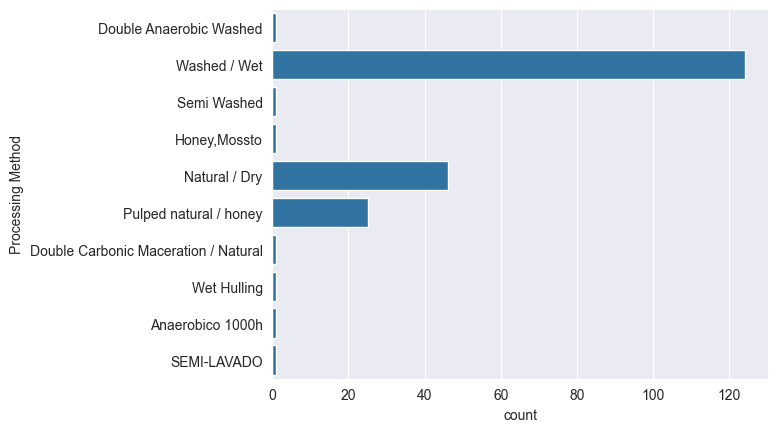

In [241]:
#Перед заполнением проверим barplot распределения
sns.countplot(y=df["Processing Method"])
plt.show()

В зависимости от типа данных и их распределений использовались разные методы заполнения Nan значений.

1. Идентификационные столбцы (имена ферм, номера партий, номера ICO) были заполнены словом «Unknown», так как эти значения представляют собой метки, а не измеряемые атрибуты.

2. Категориальные переменные, описывающие характеристики кофе, где преобладала определенная категория были заполнены модой.

In [242]:
first_group = ['ICO Number', 'Mill', 'Farm Name', 'Producer', 'Lot Number']

df["has_ios_number"] = df['ICO Number'].notna().astype(int)
df['ICO Number'] = df['ICO Number'].fillna("Unknown")

for col in first_group:
    df[col] = df[col].fillna("Unknown")



In [243]:
second_group = ['Variety', 'Processing Method']

for col in second_group:
    df[col] = df[col].fillna(df[col].mode()[0])


Групповая мода (находим моду для страны по регионам, затем при Nan значении региона смотрим на страну и выбираем моду). Предусматриваем ситуацию, когда Nan значение у страны/региона

In [244]:
df['Region'] = df.groupby('Country of Origin')['Region'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 'Unknown')
)
df['Region'] = df['Region'].fillna('Unknown')

In [245]:
df["Altitude"].dtype

<StringDtype(storage='python', na_value=nan)>

In [246]:
df['Altitude_numeric'] = df['Altitude'].str.extract(r'(\d+)').astype(float)
df['Altitude_numeric'] = df['Altitude_numeric'].fillna(df['Altitude_numeric'].median())
df['Altitude'] = df['Altitude'].fillna("Unknown")

print(df[['Altitude', 'Altitude_numeric']].head(10))

    Altitude  Altitude_numeric
0  1700-1930            1700.0
1       1200            1200.0
2       1300            1300.0
3       1900            1900.0
4  1850-2100            1850.0
5       1668            1668.0
6       1250            1250.0
7       1200            1200.0
8       1250            1250.0
9  1400-1700            1400.0


In [247]:
#проверяем нет ли больше пропусков в данных
df.isnull().sum()

Unnamed: 0               0
ID                       0
Country of Origin        0
Farm Name                0
Lot Number               0
Mill                     0
ICO Number               0
Company                  0
Altitude                 0
Region                   0
Producer                 0
Number of Bags           0
Bag Weight               0
In-Country Partner       0
Harvest Year             0
Grading Date             0
Owner                    0
Variety                  0
Status                   0
Processing Method        0
Aroma                    0
Flavor                   0
Aftertaste               0
Acidity                  0
Body                     0
Balance                  0
Uniformity               0
Clean Cup                0
Sweetness                0
Overall                  0
Defects                  0
Total Cup Points         0
Moisture Percentage      0
Category One Defects     0
Quakers                  0
Color                    0
Category Two Defects     0
E

In [248]:
#выбираем характеристики для построения предсказаний
score_cols = ['Aroma', 'Flavor', 'Aftertaste', 'Acidity', 'Body', 'Balance', 'Uniformity', 'Clean Cup', 'Sweetness', 'Overall', 'Total Cup Points']

pd.DataFrame({
    'min':    df[score_cols].min(),
    'max':    df[score_cols].max(),
    'mean':   df[score_cols].mean().round(3),
    'median': df[score_cols].median(),
    'mode':   df[score_cols].mode().iloc[0]
})

,min,max,mean,median,mode
Aroma,6.50,8.58,7.721,7.67,7.67
Flavor,6.75,8.50,7.745,7.75,7.92
Aftertaste,6.67,8.42,7.600,7.58,7.58
Acidity,6.83,8.58,7.690,7.67,7.75
Body,6.83,8.25,7.641,7.67,7.67
Balance,6.67,8.42,7.644,7.67,7.67
Uniformity,8.67,10.00,9.990,10.00,10.00
Clean Cup,10.00,10.00,10.000,10.00,10.00
Sweetness,10.00,10.00,10.000,10.00,10.00
Overall,6.67,8.58,7.677,7.67,7.75


In [249]:
df[score_cols].quantile([0.05, 0.25, 0.50, 0.75, 0.95]).T

,0.05,0.25,0.50,0.75,0.95
Aroma,7.250,7.58,7.67,7.920,8.170
Flavor,7.250,7.58,7.75,7.920,8.170
Aftertaste,7.170,7.42,7.58,7.750,8.080
Acidity,7.274,7.50,7.67,7.875,8.080
Body,7.250,7.50,7.67,7.750,8.000
Balance,7.194,7.50,7.67,7.790,8.000
Uniformity,10.000,10.00,10.00,10.000,10.000
Clean Cup,10.000,10.00,10.00,10.000,10.000
Sweetness,10.000,10.00,10.00,10.000,10.000
Overall,7.170,7.50,7.67,7.920,8.143


In [250]:
#дисперсия, асимметрия, эксцесс
pd.DataFrame({
    'Variance': df[score_cols].var().round(4),
    'Skewness': df[score_cols].skew().round(4),
    'Kurtosis': df[score_cols].kurtosis().round(4)
})

,Variance,Skewness,Kurtosis
Aroma,0.0827,-0.1128,1.1012
Flavor,0.0782,-0.2144,0.4282
Aftertaste,0.0761,-0.1899,0.8502
Acidity,0.0673,-0.1111,0.5813
Body,0.0545,-0.2961,0.6625
Balance,0.0657,-0.2266,0.8816
Uniformity,0.0107,-11.5128,138.6556
Clean Cup,0.0000,0.0000,0.0000
Sweetness,0.0000,0.0000,0.0000
Overall,0.0939,-0.0698,0.5603


использование pd.get_dummies

In [251]:
one_hot_encoder_cols = ['Processing Method', 'Color', 'Country of Origin']
df[one_hot_encoder_cols].head()

,Processing Method,Color,Country of Origin
0,Double Anaerobic Washed,green,Colombia
1,Washed / Wet,blue-green,Taiwan
2,Semi Washed,yellowish,Laos
3,Washed / Wet,green,Costa Rica
4,"Honey,Mossto",yellow-green,Colombia


In [252]:
df_encoded = pd.get_dummies(df, columns=one_hot_encoder_cols, drop_first=False)
new_cols = [c for c in df_encoded.columns if any(c.startswith(col) for col in one_hot_encoder_cols)]
df_encoded[new_cols].head()

,Processing Method_Anaerobico 1000h,Processing Method_Double Anaerobic Washed,Processing Method_Double Carbonic Maceration / Natural,"Processing Method_Honey,Mossto",Processing Method_Natural / Dry,Processing Method_Pulped natural / honey,Processing Method_SEMI-LAVADO,Processing Method_Semi Washed,Processing Method_Washed / Wet,Processing Method_Wet Hulling,...,Country of Origin_Myanmar,Country of Origin_Nicaragua,Country of Origin_Panama,Country of Origin_Peru,Country of Origin_Taiwan,"Country of Origin_Tanzania, United Republic Of",Country of Origin_Thailand,Country of Origin_Uganda,Country of Origin_United States (Hawaii),Country of Origin_Vietnam
0,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
2,False,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


Применяем Feature Hashing (hashing encoder)

In [253]:
for col, n in [('Variety', 8), ('Region', 16)]:
    hasher = FeatureHasher(n_features=n, input_type='string')
    hashed = hasher.fit_transform(df[col].apply(lambda x: [x]))
    hashed_df = pd.DataFrame(
        hashed.toarray(),
        columns=[f'{col.lower()}_hash_{i}' for i in range(n)]
    )
    df_encoded = pd.concat([df_encoded.reset_index(drop=True), hashed_df.reset_index(drop=True)], axis=1)

выбросим столбцы, которые не влияют на вкусовые качества кофе

In [254]:
drop_cols = ['Farm Name', 'Mill', 'ICO Number', 'Producer',
             'Lot Number', 'Owner', 'Company', 'Altitude',
             'Unnamed: 0', 'ID']
df_encoded = df_encoded.drop(columns=drop_cols, errors='ignore')

In [255]:
print(f"Было колонок: {df.shape[1]}")
print(f"Стало колонок: {df_encoded.shape[1]}")

Было колонок: 43
Стало колонок: 98


Создание дополнительный столбцов (признаков) - feature engineering

In [256]:
#кофе считается specialty если набирает >= 85 баллов
df['is_specialty'] = (df['Total Cup Points'] >= 85).astype(int)
print(df['is_specialty'].value_counts())

is_specialty
0    159
1     48
Name: count, dtype: int64


In [264]:
#разница между лучшей и худшей оценкой по шести вкусовым критериям
taste_cols = ['Aroma', 'Flavor', 'Aftertaste', 'Acidity', 'Body', 'Balance']
df['flavor_spread'] = df[taste_cols].max(axis=1) - df[taste_cols].min(axis=1)

In [258]:
#группируем редкие сорта в "Other"
variety_counts = df['Variety'].value_counts()

common_varieties = variety_counts[variety_counts >= 5].index

df['variety_grouped'] = df['Variety'].apply(
    lambda x: x if x in common_varieties else 'Other'
)

print(df['variety_grouped'].value_counts())

variety_grouped
Other                  55
Caturra                33
Gesha                  27
Typica                 23
Bourbon                17
Catuai                 12
unknown                12
Catimor                11
Ethiopian Heirlooms     9
SL34                    8
Name: count, dtype: int64


In [259]:
new_features = ['is_specialty', 'flavor_spread', 'variety_grouped']
df[new_features].head(10)

,is_specialty,flavor_spread,variety_grouped
0,1,0.33,Other
1,1,0.58,Gesha
2,1,0.50,Other
3,1,0.17,Gesha
4,1,0.41,Other
5,1,0.50,Gesha
6,1,0.50,Gesha
7,1,0.33,Other
8,1,0.33,SL34
9,1,0.17,Bourbon


Part E (визуализация данных с использованием библиотек)

(array([0.02558297, 0.        , 0.        , 0.        , 0.01279149,
        0.03837446, 0.06395743, 0.02558297, 0.03837446, 0.0895404 ,
        0.15349783, 0.20466378, 0.15349783, 0.20466378, 0.23024675,
        0.29420418, 0.1790808 , 0.23024675, 0.20466378, 0.1790808 ,
        0.0895404 , 0.10233189, 0.02558297, 0.03837446, 0.03837446,
        0.01279149, 0.        , 0.        , 0.        , 0.01279149]),
 array([78.        , 78.37766667, 78.75533333, 79.133     , 79.51066667,
        79.88833333, 80.266     , 80.64366667, 81.02133333, 81.399     ,
        81.77666667, 82.15433333, 82.532     , 82.90966667, 83.28733333,
        83.665     , 84.04266667, 84.42033333, 84.798     , 85.17566667,
        85.55333333, 85.931     , 86.30866667, 86.68633333, 87.064     ,
        87.44166667, 87.81933333, 88.197     , 88.57466667, 88.95233333,
        89.33      ]),
 <BarContainer object of 30 artists>)

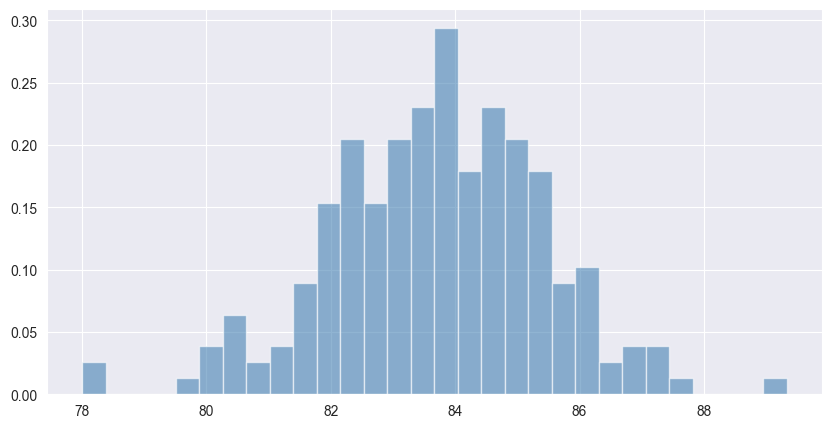

In [260]:
#matplotlib
plt.figure(figsize=(10, 5))
plt.hist(df['Total Cup Points'], bins=30, density=True, alpha=0.6, color='steelblue')

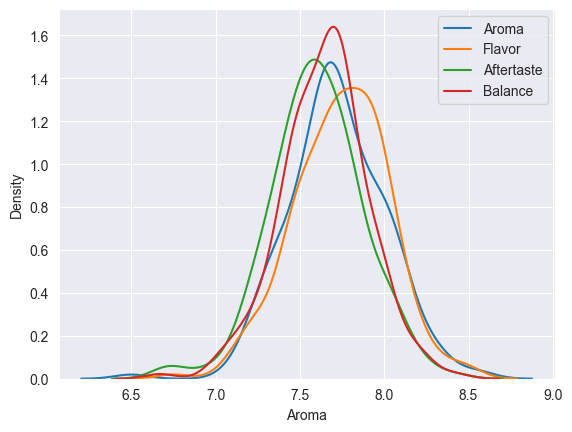

In [261]:
#seaborn
for col in ['Aroma', 'Flavor', 'Aftertaste', 'Balance']:
    sns.kdeplot(df[col], label=col)
plt.legend()

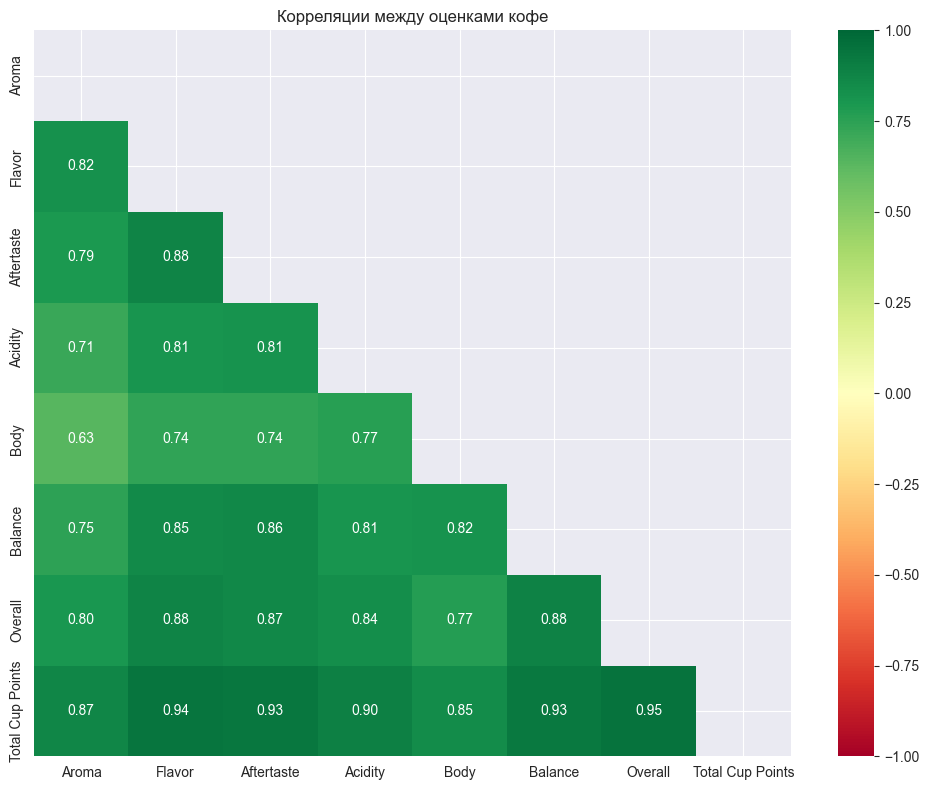

In [263]:
#корреляционная матрица для всех числовых оценок (нижнетреугольная, так как значения правого верхнего треугольника повторяются)
corr_cols = ['Aroma', 'Flavor', 'Aftertaste', 'Acidity', 'Body', 'Balance', 'Overall', 'Total Cup Points']

corr_matrix = df[corr_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn', vmin=-1, vmax=1)
plt.title('Корреляции между оценками кофе')
plt.tight_layout()
plt.show()

In [265]:
#plotly

px.scatter(
    df,
    x='Flavor',
    y='Total Cup Points',
    color='Country of Origin',
    size='Aroma',
    hover_data=['Farm Name', 'Variety', 'Processing Method']
)

F) Итоговые выводы

 Что я поняла про датасет:

- Датасет содержит 207 партий арабики из ~30 стран, оценённых профессиональными
  дегустаторами CQI по 10 критериям качества.
- Колонки Sweetness и Clean Cup почти константы (std ≈ 0, у большинства партий = 10)
  — они несут мало информации и вероятно будут слабыми признаками в модели.
- Flavor, Aroma, Balance и Overall сильнее всего коррелируют с Total Cup Points (r > 0.8)
  — именно они определяют итоговую оценку.
- Колонка Altitude хранилась как строка с диапазонами ("850-1100m") — потребовала
  дополнительной обработки для извлечения числового значения.
- Washed — самый распространённый метод обработки, остальные методы встречаются
  значительно реже, что создаёт дисбаланс в категориальном признаке.
- Пропуски сконцентрированы в идентификаторах (ICO Number — 132 пропуска) и
  описательных полях (Variety, Region) — содержательные числовые колонки пропусков
  не имеют.
- Высокая мультиколлинеарность вкусовых оценок говорит о том что дегустаторы
  оценивают кофе целостно — хороший аромат обычно сопровождается хорошим вкусом.
- flavor_spread (разброс вкусового профиля) в среднем небольшой — большинство
  партий имеют стабильный профиль без резких перепадов между критериями.

Гипотезы и наблюдения:

1. Страна происхождения влияет на оценку - на box plot видно что медианы
   разных стран заметно отличаются.

2. Natural обработка даёт более высокую Sweetness - ферментация при natural
   методе добавляет сладость зерну, это должно отражаться в оценках.

3. Выбросы связаны с дефектами - партии с низким Total Cup Points скорее
   всего имеют повышенный Category Two Defects.

4. Высокогорный кофе получает более высокую Acidity - прохладный климат
   замедляет созревание и повышает кислотность.


Следующие этапы:

Модель: я бы начала с Random Forest Regressor - хорошо работает с мультиколлинеарными
признаками, не требует нормализации, устойчив к выбросам. Затем сравнила с
Gradient Boosting (XGBoost или LightGBM).

Признаки для модели: Flavor, Aroma, Aftertaste, Balance, Overall,
country_encoded (OHE), proc_* (OHE), variety_hash_*, region_hash_*,
flavor_spread, total_defects, Altitude_numeric, grading_month.

Следует удалить столбцы Sweetness, Clean Cup, Uniformity (низкая вариация),
все идентификаторы (Farm Name, ICO Number, ID).

Валидация: кросс-валидация 5-fold, метрика RMSE.


Какие подсказки брала у AI и что проверяла сама:

AI подсказал идею использовать `groupby + transform` вместо глобальной моды.
Также AI объяснил концепцию и почему данные нужно оборачивать в список через `.apply(lambda x: [x])`
и почему для Region взяли n=16 а не 8 — больше уникальных значений требует
больше хэш-колонок для снижения коллизий.

Что делала полностью сама:
Заполняла пропуски, выбирала способы кодировки переменных и удаляла ненужные столбцы, сделала выводы по heatmap корреляций, визуализацию данных.